# 01 — Linear Classifiers: SVM & Softmax

Train, evaluate and save both classifiers on CIFAR-10.

Correctness checks (gradient checking, naive-vs-vectorized) belong in `tests/`, not here.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
import torch

import dl
from dl.paths import REPO_ROOT
from dl.datasets import CLASSES
from dl.utils import accuracy, visualize_linear_weights
from dl.models.linear_classifier import LinearSVM, Softmax, tune

# CPU is plenty here — a 200x3073 matmul is too small for the GPU to help.
USE_CUDA = False
CUDA = USE_CUDA and torch.cuda.is_available()
print('device:', 'cuda' if CUDA else 'cpu')

device: cpu


In [3]:
dl.reset_seed(0)

data = dl.datasets.preprocess_cifar10(
    bias_trick=True,      # appends the constant-1 column -> D = 3073
    cuda=CUDA,
    dtype=torch.float64,
    show_examples=False,  # set True to eyeball the images
)

for k in ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']:
    print(f'{k:8s} {str(tuple(data[k].shape)):16s} {data[k].dtype}')

CKPT_DIR = REPO_ROOT / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

/home/saisampathkedari/Deep-Learning/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


X_train  (40000, 3073)    torch.float64
y_train  (40000,)         torch.int64
X_val    (10000, 3073)    torch.float64
y_val    (10000,)         torch.int64
X_test   (10000, 3073)    torch.float64
y_test   (10000,)         torch.int64


---
## SVM

In [4]:
dl.reset_seed(0)

svm = LinearSVM()
svm.train(data['X_train'], data['y_train'],
          learning_rate=1e-2, reg=1e-3, num_iters=1500, verbose=True)

print(f"\ntrain {accuracy(svm.predict(data['X_train']), data['y_train']):.4f}")
print(f"val   {accuracy(svm.predict(data['X_val']),   data['y_val']):.4f}")

iteration 0 / 1500: loss 9.000019
iteration 100 / 1500: loss 5.227930
iteration 200 / 1500: loss 4.492208
iteration 300 / 1500: loss 4.382729
iteration 400 / 1500: loss 4.200244
iteration 500 / 1500: loss 4.144373
iteration 600 / 1500: loss 4.126453
iteration 700 / 1500: loss 3.864670
iteration 800 / 1500: loss 4.644966
iteration 900 / 1500: loss 4.404462
iteration 1000 / 1500: loss 3.755225
iteration 1100 / 1500: loss 3.929645
iteration 1200 / 1500: loss 3.871866
iteration 1300 / 1500: loss 4.277652
iteration 1400 / 1500: loss 3.919348

train 0.4082
val   0.3849


test  0.3818
Saved in /home/saisampathkedari/Deep-Learning/checkpoints/svm.pt


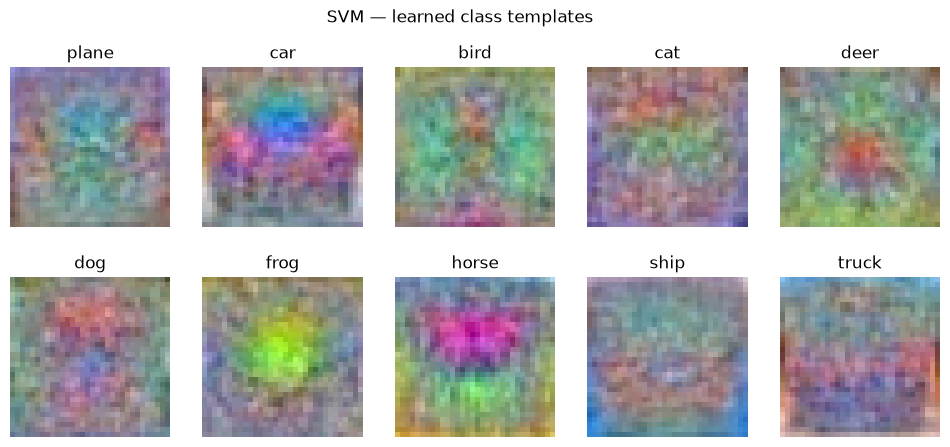

In [5]:
print(f"test  {accuracy(svm.predict(data['X_test']), data['y_test']):.4f}")
svm.save(str(CKPT_DIR / 'svm.pt'))

# Each column of W is a template the class is matched against, so it should
# look faintly like the class: a red blob for car, a blue band for ship.
visualize_linear_weights(svm.W, CLASSES, title='SVM — learned class templates')

---
## Softmax

In [6]:
dl.reset_seed(0)

softmax = Softmax()
softmax.train(data['X_train'], data['y_train'],
              learning_rate=1e-1, reg=1e-5, num_iters=1500, verbose=True)

print(f"\ntrain {accuracy(softmax.predict(data['X_train']), data['y_train']):.4f}")
print(f"val   {accuracy(softmax.predict(data['X_val']),   data['y_val']):.4f}")

iteration 0 / 1500: loss 2.302587
iteration 100 / 1500: loss 1.868552
iteration 200 / 1500: loss 1.716321
iteration 300 / 1500: loss 1.690719
iteration 400 / 1500: loss 1.682156
iteration 500 / 1500: loss 1.676901
iteration 600 / 1500: loss 1.660033
iteration 700 / 1500: loss 1.610928
iteration 800 / 1500: loss 1.774619
iteration 900 / 1500: loss 1.732221
iteration 1000 / 1500: loss 1.578540
iteration 1100 / 1500: loss 1.612318
iteration 1200 / 1500: loss 1.654018
iteration 1300 / 1500: loss 1.704474
iteration 1400 / 1500: loss 1.653607

train 0.4315
val   0.4000


test  0.4034
Saved in /home/saisampathkedari/Deep-Learning/checkpoints/softmax.pt


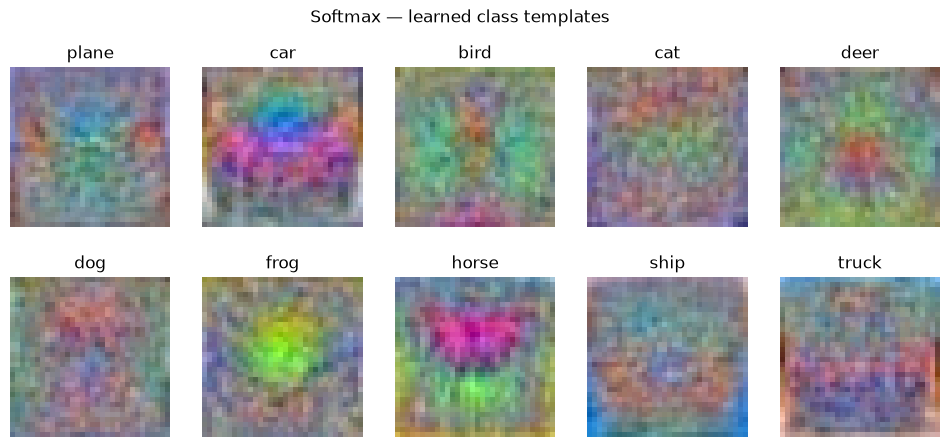

In [7]:
print(f"test  {accuracy(softmax.predict(data['X_test']), data['y_test']):.4f}")
softmax.save(str(CKPT_DIR / 'softmax.pt'))
visualize_linear_weights(softmax.W, CLASSES, title='Softmax — learned class templates')

---
## Hyperparameter search

How the values above were found. Swap `LinearSVM` for `Softmax` to search the other.

In [8]:
best_svm, best_val, results = tune(
    LinearSVM,
    data,
    learning_rates=[3e-3, 1e-2, 3e-2, 1e-1],
    regularization_strengths=[1e-5, 1e-4, 1e-3, 1e-2],
    num_iters=1500,
)

lr 3.0e-03  reg 1.0e-05   train 0.4004   val 0.3764
lr 3.0e-03  reg 1.0e-04   train 0.4002   val 0.3770
lr 3.0e-03  reg 1.0e-03   train 0.4004   val 0.3770
lr 3.0e-03  reg 1.0e-02   train 0.4001   val 0.3768
lr 1.0e-02  reg 1.0e-05   train 0.4082   val 0.3846
lr 1.0e-02  reg 1.0e-04   train 0.4084   val 0.3845
lr 1.0e-02  reg 1.0e-03   train 0.4082   val 0.3849
lr 1.0e-02  reg 1.0e-02   train 0.4073   val 0.3819
lr 3.0e-02  reg 1.0e-05   train 0.4064   val 0.3679
lr 3.0e-02  reg 1.0e-04   train 0.4068   val 0.3680
lr 3.0e-02  reg 1.0e-03   train 0.4055   val 0.3666
lr 3.0e-02  reg 1.0e-02   train 0.4010   val 0.3704
lr 1.0e-01  reg 1.0e-05   train 0.3619   val 0.3201
lr 1.0e-01  reg 1.0e-04   train 0.3645   val 0.3269
lr 1.0e-01  reg 1.0e-03   train 0.3669   val 0.3287
lr 1.0e-01  reg 1.0e-02   train 0.3318   val 0.3066

best validation accuracy: 0.3849
